In [1]:
import sys
sys.path.append('../../../../../src')
sys.path.append('../../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.greedy import GreedyLineSearch

from tests.experimental.converters.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../../fonts/OpenSans-Regular.ttf"
FONT_SIZE = 11
IMG_SET_PATH = "../../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return GreedyLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0144 | Max: 0.1796 | Mean: 0.0996 | Std: 0.0646
Min: 0.0259 | Max: 0.0698 | Mean: 0.0497 | Std: 0.0186
Min: 0.0241 | Max: 0.1222 | Mean: 0.0662 | Std: 0.0321
Min: 0.0479 | Max: 0.0953 | Mean: 0.0718 | Std: 0.0161


C:\Users\wojte\AppData\Local\Temp\ipykernel_5692\2873555137.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


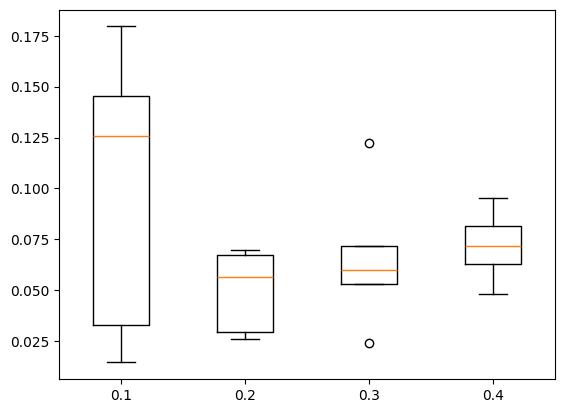

In [2]:
# scale

params_space = [
    {'scale_factor': 0.1},
    {'scale_factor': 0.2},
    {'scale_factor': 0.3},
    {'scale_factor': 0.4},
]

params_space = list(
    map(lambda preprocess_args: Params(
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['scale_factor'] for param in params_space])
plt.show()

Min: 0.0563 | Max: 0.1172 | Mean: 0.0863 | Std: 0.0226
Min: 0.0174 | Max: 0.0851 | Mean: 0.0583 | Std: 0.0252
Min: 0.0366 | Max: 0.2082 | Mean: 0.1000 | Std: 0.0643
Min: 0.0681 | Max: 0.1529 | Mean: 0.1058 | Std: 0.0314


C:\Users\wojte\AppData\Local\Temp\ipykernel_5692\3258563153.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


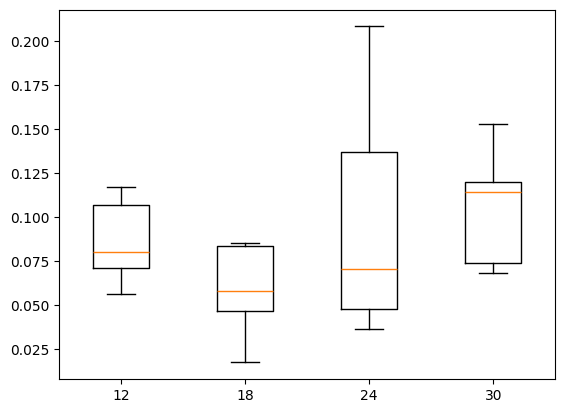

In [3]:
# font size

params_space = [
    s for s in range(12, 32, 6)
]

params_space = list(
    map(lambda s: Params(
        font_path=FONT_PATH,
        font_size=s,
        converter_args={},
        preprocess_args={'scale_factor': 0.3}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.font_size for param in params_space])
plt.show()

Min: 0.0248 | Max: 0.1129 | Mean: 0.0546 | Std: 0.0335
Min: 0.0259 | Max: 0.1215 | Mean: 0.0610 | Std: 0.0341
Min: 0.0767 | Max: 0.1400 | Mean: 0.0905 | Std: 0.0248
Min: 0.0850 | Max: 0.1494 | Mean: 0.1109 | Std: 0.0258
Min: 0.0935 | Max: 0.1495 | Mean: 0.1191 | Std: 0.0247


C:\Users\wojte\AppData\Local\Temp\ipykernel_5692\3906144444.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


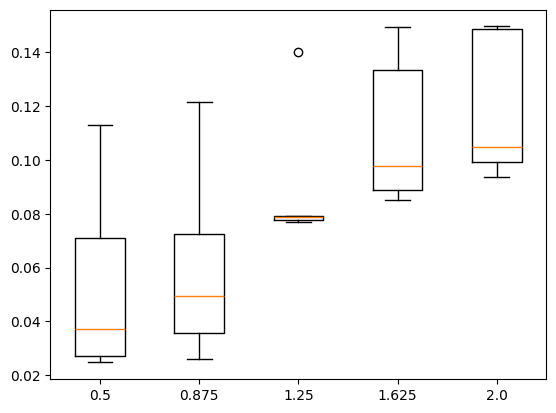

In [4]:
# contrast

params_space = [
    {'contrast': c, 'scale_factor': 0.3} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()